In [13]:
import numpy as np
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# 1. Define exact paths based on Kaggle scan results
TRAIN_DIR = "/kaggle/input/datasets/msambare/fer2013/train"
TEST_DIR  = "/kaggle/input/datasets/msambare/fer2013/test"

# 2. Set constants for consistency
IMG_SIZE = (48, 48)  # FER2013 images are 48x48 pixels
BATCH_SIZE = 64      # Number of images processed at once
EPOCHS = 30          # Number of training rounds

# Initial classes in the dataset (7 classes)
CLASSES = ['angry','disgust','fear','happy','neutral','sad','surprise']

In [14]:
# 1. Data Augmentation: artificially increases dataset size by transforming images
train_gen = ImageDataGenerator(
    rescale=1./255,           # Normalize pixels (0-255 to 0-1)
    validation_split=0.2,     # Reserve 20% for validation
    rotation_range=15,        # Randomly rotate images
    width_shift_range=0.1,    # Randomly shift horizontally
    height_shift_range=0.1,   # Randomly shift vertically
    zoom_range=0.1,           # Randomly zoom in/out
    horizontal_flip=True      # Flip images (faces look both ways)
)

# 2. Standard generator for training and validation
raw_train = train_gen.flow_from_directory(
    TRAIN_DIR, target_size=IMG_SIZE, color_mode="grayscale",
    batch_size=BATCH_SIZE, class_mode="sparse", subset="training", shuffle=True)

raw_val = train_gen.flow_from_directory(
    TRAIN_DIR, target_size=IMG_SIZE, color_mode="grayscale",
    batch_size=BATCH_SIZE, class_mode="sparse", subset="validation", shuffle=False)

# 3. MERGE LOGIC : Combines 'Disgust' (label 1) into 'Angry' (label 0)
def merge_classes(generator):
    while True:
        x, y = next(generator)
        y = np.where(y == 1, 0, y)    # Change label 1 to 0
        y = np.where(y > 1, y - 1, y) # Shift labels 2-6 to 1-5
        yield x, y

# Final 6-class generators
train_data_6 = merge_classes(raw_train)
val_data_6 = merge_classes(raw_val)

Found 22968 images belonging to 7 classes.
Found 5741 images belonging to 7 classes.


In [15]:
def build_improved_cnn():
    model = models.Sequential([
        # FIRST BLOCK: Detecting basic edges and textures
        layers.Conv2D(64, (5, 5), input_shape=(48, 48, 1), activation='relu', padding='same'),
        layers.BatchNormalization(), 
        layers.Conv2D(64, (5, 5), activation='relu', padding='same'),
        layers.BatchNormalization(),
        layers.MaxPooling2D(pool_size=(2, 2)), 

        # SECOND BLOCK: Detecting complex features (eyes, nose, mouth)
        layers.Conv2D(128, (5, 5), activation='relu', padding='same'),
        layers.BatchNormalization(),
        layers.MaxPooling2D(pool_size=(2, 2)),

        # THIRD BLOCK: Deep feature extraction
        layers.Conv2D(256, (3, 3), activation='relu', padding='same'),
        layers.BatchNormalization(),
        layers.MaxPooling2D(pool_size=(2, 2)),

        # CLASSIFIER HEAD: Converting visual data into emotion labels
        layers.Flatten(),
        layers.Dense(128, activation='relu'),
        layers.BatchNormalization(),
        layers.Dropout(0.5), 
        layers.Dense(6, activation='softmax') 
    ])

    # Updated Optimizer with lower learning rate for better precision
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001), 
        loss='sparse_categorical_crossentropy', 
        metrics=['accuracy']
    )
    
    return model

# Initialize the model
my_model = build_improved_cnn()
my_model.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_12 (Conv2D)              │ (None, 48, 48, 64)     │         1,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_15          │ (None, 48, 48, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_13 (Conv2D)              │ (None, 48, 48, 64)     │       102,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_16          │ (None, 48, 48, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_9 (MaxPooling2D)  │ (None, 24, 24, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_14 (Conv2D)              │ (None, 24, 24, 128)    │       204,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_17          │ (None, 24, 24, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_10 (MaxPooling2D) │ (None, 12, 12, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_15 (Conv2D)              │ (None, 12, 12, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_18          │ (None, 12, 12, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_11 (MaxPooling2D) │ (None, 6, 6, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_3 (Flatten)             │ (None, 9216)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 128)            │     1,179,776 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_19          │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 6)              │           774 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,787,334 (6.82 MB)

 Trainable params: 1,786,054 (6.81 MB)

 Non-trainable params: 1,280 (5.00 KB)

In [16]:
# 1. Start the training process
history = my_model.fit(
    train_data_6,
    validation_data=val_data_6,
    epochs=EPOCHS,
    steps_per_epoch=len(raw_train),
    validation_steps=len(raw_val)
)

# 2. Save the final model for your project submission
my_model.save("final_6class_emotion_model.h5")
print("Model trained and saved as final_6class_emotion_model.h5")

Epoch 1/30
359/359 ━━━━━━━━━━━━━━━━━━━━ 51s 123ms/step - accuracy: 0.2214 - loss: 2.4478 - val_accuracy: 0.2552 - val_loss: 3.0198
Epoch 2/30
359/359 ━━━━━━━━━━━━━━━━━━━━ 37s 103ms/step - accuracy: 0.2851 - loss: 2.0658 - val_accuracy: 0.3688 - val_loss: 1.6008
Epoch 3/30
359/359 ━━━━━━━━━━━━━━━━━━━━ 37s 102ms/step - accuracy: 0.3329 - loss: 1.8738 - val_accuracy: 0.3728 - val_loss: 1.6131
Epoch 4/30
359/359 ━━━━━━━━━━━━━━━━━━━━ 38s 105ms/step - accuracy: 0.3689 - loss: 1.7528 - val_accuracy: 0.4191 - val_loss: 1.5108
Epoch 5/30
359/359 ━━━━━━━━━━━━━━━━━━━━ 37s 103ms/step - accuracy: 0.4016 - loss: 1.6456 - val_accuracy: 0.4332 - val_loss: 1.4522
Epoch 6/30
359/359 ━━━━━━━━━━━━━━━━━━━━ 37s 104ms/step - accuracy: 0.4275 - loss: 1.5575 - val_accuracy: 0.4720 - val_loss: 1.3504
Epoch 7/30
359/359 ━━━━━━━━━━━━━━━━━━━━ 34s 94ms/step - accuracy: 0.4505 - loss: 1.4662 - val_accuracy: 0.4903 - val_loss: 1.3230
Epoch 8/30
359/359 ━━━━━━━━━━━━━━━━━━━━ 32s 89ms/step - accuracy: 0.4677 - loss: 1.4

Model trained and saved as final_6class_emotion_model.h5


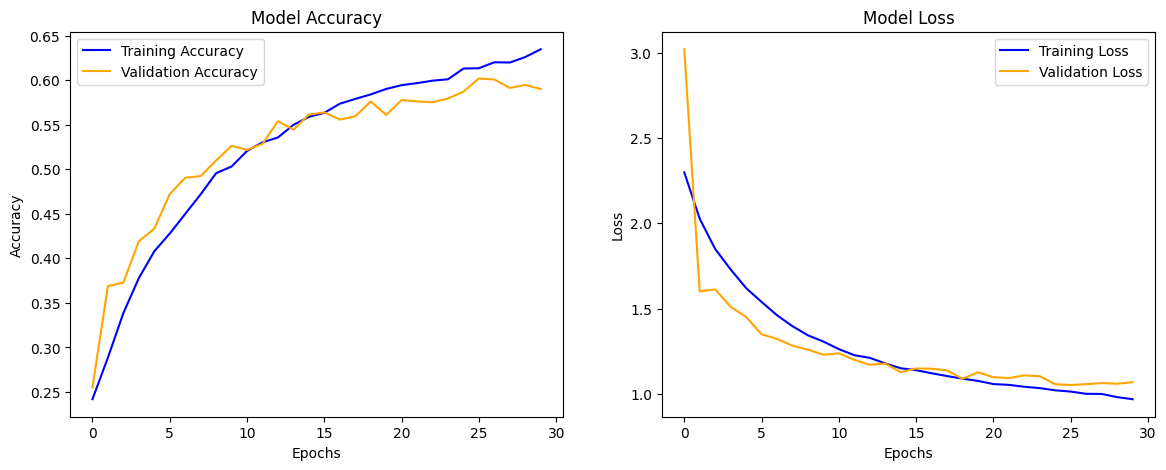

In [20]:
import matplotlib.pyplot as plt

# 1. Plot Accuracy & Loss
plt.figure(figsize=(14, 5))

# Accuracy Plot
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Training Accuracy', color='blue')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy', color='orange')
plt.title('Model Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

# Loss Plot
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Training Loss', color='blue')
plt.plot(history.history['val_loss'], label='Validation Loss', color='orange')
plt.title('Model Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.show()

90/90 ━━━━━━━━━━━━━━━━━━━━ 7s 76ms/step


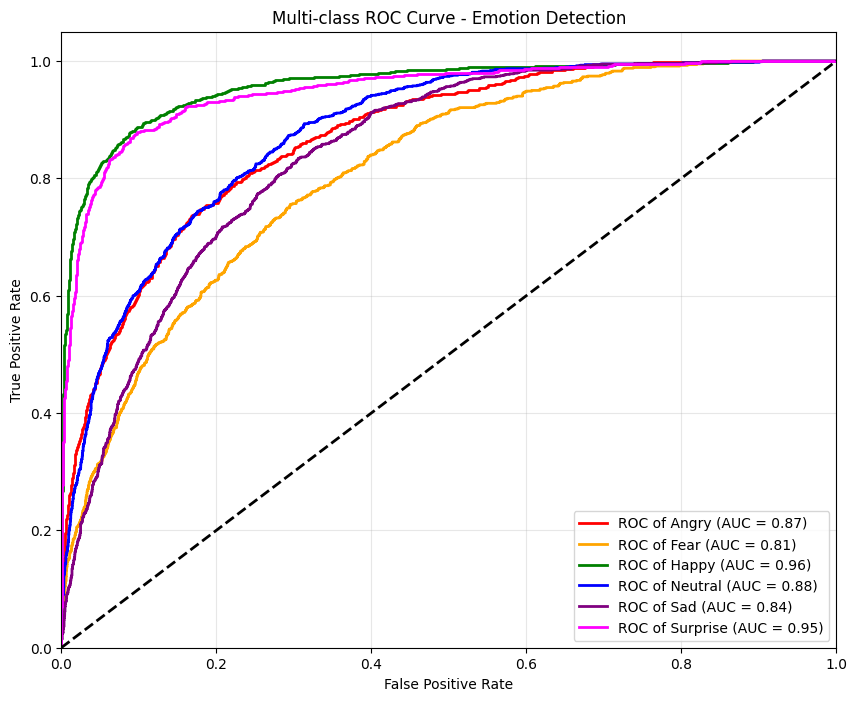

In [21]:
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize
import matplotlib.pyplot as plt
import numpy as np

# 1. Prepare Data
raw_val.reset()
y_probs = my_model.predict(val_data_6, steps=len(raw_val))
y_true = raw_val.classes.copy()
y_true = np.where(y_true == 1, 0, y_true)    # Merge Disgust to Angry
y_true = np.where(y_true > 1, y_true - 1, y_true) # Shift labels

# Binarize labels for multiclass ROC
n_classes = 6
y_true_bin = label_binarize(y_true, classes=[0, 1, 2, 3, 4, 5])
emotions = ['Angry', 'Fear', 'Happy', 'Neutral', 'Sad', 'Surprise']

# 2. Calculate ROC and AUC for each class
fpr = dict()
tpr = dict()
roc_auc = dict()

for i in range(n_classes):
    fpr[i], tpr[i], _ = roc_curve(y_true_bin[:, i], y_probs[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

# 3. Plot ROC Curves
plt.figure(figsize=(10, 8))
colors = ['red', 'orange', 'green', 'blue', 'purple', 'magenta']
for i, color in zip(range(n_classes), colors):
    plt.plot(fpr[i], tpr[i], color=color, lw=2,
             label=f'ROC of {emotions[i]} (AUC = {roc_auc[i]:.2f})')

plt.plot([0, 1], [0, 1], 'k--', lw=2)
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Multi-class ROC Curve - Emotion Detection')
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.show()

Testing with file: /kaggle/input/datasets/msambare/fer2013/test/happy/PrivateTest_6781468.jpg
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 946ms/step


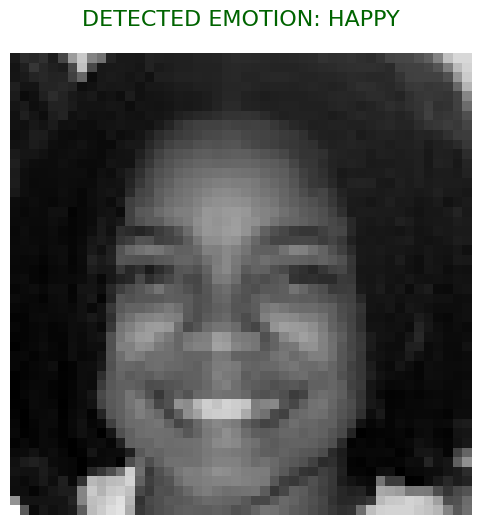

AI ANALYSIS: The user appears to be HAPPY.
MUSIC RECOMMENDATIONS:
   1. Upbeat Pop
   2. Dance/Electronic
   3. Funk & Soul


In [26]:
import matplotlib.pyplot as plt
import numpy as np
import os
from tensorflow.keras.preprocessing import image

# ==========================================
# STEP 1: MUSIC RECOMMENDATION LOGIC
# ==========================================
# This function acts as the "Application Layer" of our project.
# It maps the predicted emotion label to a specific list of music genres.
def recommend_music(emotion):
    music_map = {
        'happy': ["Upbeat Pop", "Dance/Electronic", "Funk & Soul"],
        'sad': ["Soulful Blues", "Soft Instrumental", "Rainy Day Melodies"],
        'angry': ["Hard Rock", "Heavy Metal", "High-Energy Workout"],
        'fear': ["Calming Nature Sounds", "Ambient Lo-fi", "Deep Focus"],
        'neutral': ["Classical Piano", "Acoustic Guitar", "Jazz"],
        'surprise': ["Electronic / Future Bass", "Alternative Rock", "Experimental Pop"]
    }
    return music_map.get(emotion, ["General Relaxation"])

# ==========================================
# STEP 2: PREDICTION & VISUALIZATION FUNCTION
# ==========================================
# This function handles the entire pipeline: Image Loading -> Preprocessing -> AI Prediction -> Recommendation
def predict_and_show_result(img_path):
    # Check if the file exists to avoid program crashes
    if not os.path.exists(img_path):
        print(f"ERROR: File not found at {img_path}")
        return

    # 1. Load and Preprocess: Resize to 48x48 and convert to Grayscale as per FER2013 standards
    img = image.load_img(img_path, target_size=(48, 48), color_mode="grayscale")
    img_array = image.img_to_array(img)
    img_array = np.expand_dims(img_array, axis=0) # Add batch dimension (1, 48, 48, 1)
    img_array /= 255.0  # Normalize pixel values to range [0, 1]
    
    # 2. Model Inference: Get probability scores for each of the 6 classes
    preds = my_model.predict(img_array)
    emotion_labels = ['angry', 'fear', 'happy', 'neutral', 'sad', 'surprise']
    
    # Find the label with the highest probability
    predicted_emotion = emotion_labels[np.argmax(preds)]
    
    # 3. Visualization: Displaying the image with the AI's conclusion
    plt.figure(figsize=(6, 6))
    plt.imshow(img, cmap='gray')
    plt.title(f"DETECTED EMOTION: {predicted_emotion.upper()}", fontsize=16, color='darkgreen', pad=20)
    plt.axis('off')
    plt.show()
    
    # 4. Result Output: Printing the music suggestions to the console
    suggestions = recommend_music(predicted_emotion)
    print("="*50)
    print(f"AI ANALYSIS: The user appears to be {predicted_emotion.upper()}.")
    print(f"MUSIC RECOMMENDATIONS:")
    for i, genre in enumerate(suggestions, 1):
        print(f"   {i}. {genre}")
    print("="*50)

# ==========================================
# STEP 3: DYNAMIC PATH EXECUTION
# ==========================================
# Instead of a hardcoded filename, we look into the 'happy' folder and pick the first file.
test_folder = "/kaggle/input/datasets/msambare/fer2013/test/happy/"
available_files = os.listdir(test_folder)

if len(available_files) > 0:
    # Use the first image found in the folder
    test_image_path = os.path.join(test_folder, available_files[0])
    print(f"Testing with file: {test_image_path}")
    
    # Execute the final prediction
    predict_and_show_result(test_image_path)
else:
    print("No images found in the specified folder.")

Testing SURPRISE category with file: /kaggle/input/datasets/msambare/fer2013/test/surprise/PublicTest_78686873.jpg
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step


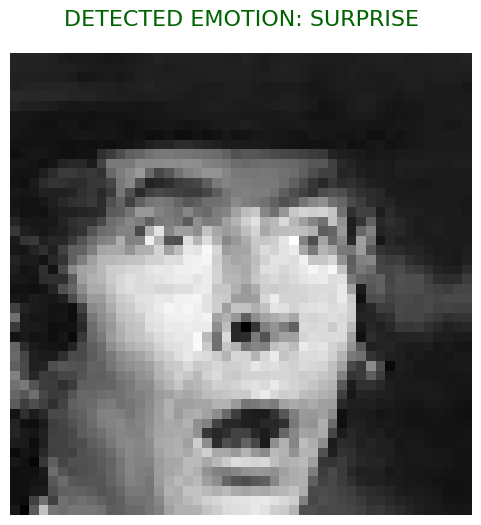

AI ANALYSIS: The user appears to be SURPRISE.
MUSIC RECOMMENDATIONS:
   1. Electronic / Future Bass
   2. Alternative Rock
   3. Experimental Pop


In [31]:
# --- TEST 2: SURPRISE EMOTION ---
# 1. Define the path to the 'surprise' folder based on your Kaggle structure
surprise_folder = "/kaggle/input/datasets/msambare/fer2013/test/surprise/"
surprise_files = os.listdir(surprise_folder)

if len(surprise_files) > 0:
    # 2. Dynamically pick the first image in the 'surprise' folder
    test_path_surprise = os.path.join(surprise_folder, surprise_files[0])
    print(f"Testing SURPRISE category with file: {test_path_surprise}")
    
    # 3. Execute the prediction and music recommendation function
    predict_and_show_result(test_path_surprise)
else:
    print("No images found in the 'surprise' folder.")

Testing NEUTRAL category with file: /kaggle/input/datasets/msambare/fer2013/test/neutral/PublicTest_85967214.jpg
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step


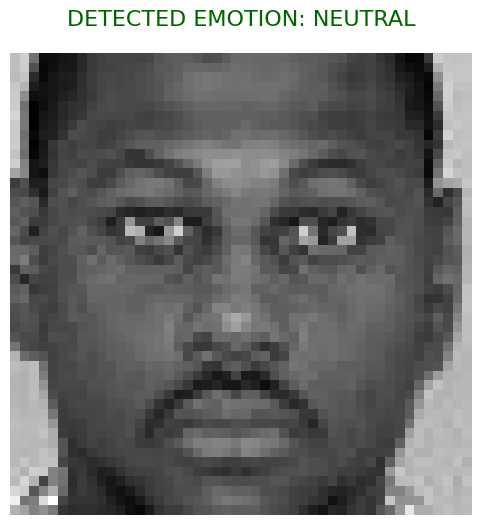

AI ANALYSIS: The user appears to be NEUTRAL.
MUSIC RECOMMENDATIONS:
   1. Classical Piano
   2. Acoustic Guitar
   3. Jazz


In [33]:
# --- TEST 3: NEUTRAL EMOTION ---
# 1. Path to the 'neutral' folder
neutral_folder = "/kaggle/input/datasets/msambare/fer2013/test/neutral/"
neutral_files = os.listdir(neutral_folder)

if len(neutral_files) > 0:
    # 2. Pick the first image in the 'neutral' folder
    test_path_neutral = os.path.join(neutral_folder, neutral_files[0])
    print(f"Testing NEUTRAL category with file: {test_path_neutral}")
    
    # 3. Run the prediction function
    predict_and_show_result(test_path_neutral)
else:
    print("No images found in the 'neutral' folder.")